In [1]:
import torch
import numpy as np
from PIL import Image
from diffusers import StableDiffusionXLPipeline, DDIMScheduler
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import math
import random
import torch.nn.functional as F
from utils import *
from transformation_functions import *
from custom_cross_attention import *

/home/kemove/anaconda3/envs/imagic/lib/python3.9/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
device = "cuda" 
torch_dtype = torch.float16
print(f"device: {device}, precision: {torch_dtype}")

prompt1 = "oil painting of a girl"
prompt2 = "oil painting of an elderly man" 
negative_prompt = ""
inner_loop = 5
amp_coeff = 1
seed = 700

noise1_attn_list = []
noise2_attn_list = []

prompt1_idxs = get_words_idx_in_a_text(prompt1)
prompt2_idxs = get_words_idx_in_a_text(prompt2)

# transformation, inverse_transformation = horizontal_flip_transformation()
# transformation, inverse_transformation = rotate_90_transformation()
transformation, inverse_transformation = rotate_180_transformation()
# transformation, inverse_transformation = diagonal_flip()

device: cuda, precision: torch.float16


In [3]:
def set_seed(seed=42):
    """set all random seeds to ensure reproducibility"""
    # 1. Python random module
    random.seed(seed)
    # 2. NumPy
    np.random.seed(seed)
    # 3. PyTorch CPU
    torch.manual_seed(seed)
    # 4. PyTorch CUDA
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        # CUDA deterministic setting
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        # use deterministic algorithms
        torch.use_deterministic_algorithms(True, warn_only=True)
        
set_seed(seed)

In [4]:
def load_turbo_pipeline():
    print("load SDXL Turbo model...")
    pipe = StableDiffusionXLPipeline.from_pretrained(
        "stabilityai/sdxl-turbo",
        torch_dtype=torch_dtype,
        variant="fp16",
        use_safetensors=True
    ).to(device)
    
    # Turbo model uses Euler Ancestral scheduler for better performance
    from diffusers import EulerAncestralDiscreteScheduler
    scheduler_config = pipe.scheduler.config
    scheduler_config.eta = 0.0  # eliminate randomness
    
    pipe.scheduler = EulerAncestralDiscreteScheduler.from_config(
        scheduler_config,
        timestep_spacing="trailing",
        eta=0.0  # set eta to 0
    )
    return pipe

In [5]:
def freeze_parameters(pipe):
    for param in pipe.unet.parameters():
        param.requires_grad = False
        
    for param in pipe.vae.parameters():
        param.requires_grad = False
        
    for param in pipe.text_encoder.parameters():
        param.requires_grad = False
    for param in pipe.text_encoder_2.parameters():
        param.requires_grad = False

In [6]:
def _get_text_embeddings_sdxl(pipe, prompt, device, torch_dtype):
    """encode SDXL Turbo text prompt"""
    
    if prompt == "":
        # return zero vector
        return torch.zeros((1, 77, 2048), device=device, dtype=torch_dtype), \
               torch.zeros((1, 1280), device=device, dtype=torch_dtype)
    
    # use pipeline encode_prompt method provided by the pipeline
    with torch.no_grad():
        (prompt_embeds, 
         negative_prompt_embeds, 
         pooled_prompt_embeds, 
         negative_pooled_prompt_embeds) = pipe.encode_prompt(
            prompt=prompt,
            negative_prompt="",  # only encode positive prompts
            device=device
        )
    return prompt_embeds, pooled_prompt_embeds

In [7]:
def latents_to_image(pipe, latents1, latents2):
        # scale the latents
        scaling_factor = pipe.vae.config.scaling_factor
        latents1 = latents1 / scaling_factor
        latents2 = latents2 / scaling_factor
    
        with torch.no_grad():
            # temporarily convert VAE to float32 to avoid numerical issues
            original_dtype = pipe.vae.dtype
            pipe.vae = pipe.vae.to(dtype=torch.float32)
            image1 = pipe.vae.decode(latents1.to(torch.float32)).sample
            image2 = pipe.vae.decode(latents2.to(torch.float32)).sample

            image1 = (image1 + inverse_transformation(image2)) / 2
            image2 = (image2 + transformation(image1)) / 2
        
        # restore the original accuracy
        pipe.vae = pipe.vae.to(dtype=original_dtype)

        def post_processing(image):
            # convert torch to PIL
            image = (image / 2 + 0.5).clamp(0, 1)
            image = image.cpu().permute(0, 2, 3, 1).float().numpy()
            image = (image[0] * 255).astype(np.uint8)
            return Image.fromarray(image)
    
        image1 = post_processing(image1)
        image2 = post_processing(image2)
        return image1, image2

In [8]:
def structure_alignment_loss(latents1, latents2):
    latents1_low = low_pass_DCT_filtering(latents1, 5)
    latents2_low = low_pass_DCT_filtering(latents2, 5)
    loss = F.mse_loss(latents1_low, latents2_low, reduction='sum')
    return loss

def semantic_enhancement_loss(noise1_attn, noise2_attn):
    return 1-(torch.mean(noise1_attn) + torch.mean(noise2_attn))

In [9]:
def sdxl_turbo_sampling(pipe, num_inference_steps=4, guidance_scale=3.0, seed=seed, 
                        prompt1=prompt1, prompt2=prompt2, negative_prompt=negative_prompt,
                        custom_attention_hooks=None):
    print(f"\nparameters:")
    print(f"  prompt1: {prompt1}")
    print(f"  prompt2: {prompt2}")
    print(f"  sampling steps: {num_inference_steps} (Turbo model only requires 1 to 4 steps)")
    print(f"  guidance_scale: {guidance_scale} (usually 0.0 for Turbo)")
    print(f"  image resolution: 512x512 (standard resolution of the Turbo model)")

    # replace cross-attention layers
    print("replace cross-attention layers as the customized ones...")
    replaced_layers = replace_cross_attention_layers(pipe.unet)
    print(f"successfully replace {len(replaced_layers)} cross-attention layers")

    global noise1_attn_list
    global noise2_attn_list

    # set customized hook functions
    if custom_attention_hooks:
        setup_custom_attention_hooks(pipe.unet, custom_attention_hooks)

    with torch.no_grad():
        # conditional text prompt
        prompt1_embeds, pooled_prompt1_embeds = _get_text_embeddings_sdxl(
            pipe, prompt1, device, torch_dtype
        )

        prompt2_embeds, pooled_prompt2_embeds = _get_text_embeddings_sdxl(
            pipe, prompt2, device, torch_dtype
        )
        
        # unconditional text prompt
        negative_prompt_embeds, negative_pooled_prompt_embeds = _get_text_embeddings_sdxl(
            pipe, negative_prompt, device, torch_dtype
        )

    # prepare initial noise
    print("prepare initial noise...")

    # Turbo model use 512x512 image resolution
    latents = torch.randn(
        (1, pipe.unet.config.in_channels, 64, 64),  # 512/8 = 64
        device=device,
        dtype=torch_dtype
    )

    # set the scheduler
    pipe.scheduler.set_timesteps(num_inference_steps, device=device)
    timesteps = pipe.scheduler.timesteps
    print(f"\ntime steps: {len(timesteps)} steps")

    # start Turbo sampling loop
    print("\nstart Turbo sampling loop...")

    # prepare time ID (Turbo use 512x512)
    add_time_ids = pipe._get_add_time_ids(
        (512, 512),  # original_size
        (0, 0),      # crops_coords_top_left
        (512, 512),  # target_size
        dtype=torch_dtype,
        text_encoder_projection_dim=pipe.text_encoder_2.config.projection_dim
    ).to(device)

    added_cond_kwargs = {
            "text_embeds": torch.cat([negative_pooled_prompt_embeds] * 4),
            "time_ids": add_time_ids.repeat(4, 1)
    }

    latents = latents * amp_coeff

    for i, t in enumerate(tqdm(timesteps, desc="Turbo sampling")):

        # build trainable parameters
        latents = latents.clone().detach().requires_grad_(True)
        negative_prompt1_embeds = negative_prompt_embeds.clone().detach().requires_grad_(True)
        negative_prompt2_embeds = negative_prompt_embeds.clone().detach().requires_grad_(True)

        # build optimizer
        structure_opt = torch.optim.SGD([negative_prompt1_embeds, negative_prompt2_embeds], lr=0.1)
        semantic_opt = torch.optim.SGD([latents], lr=0.5)

        if i < 2:
            # start inner loop for optimization
            original_step_index = pipe.scheduler._step_index
            for epoch in range(inner_loop):   # 0 ~ inner_loop - 1
                
                structure_opt.zero_grad()
                semantic_opt.zero_grad()
    
                # augments latents for CFG
                latent_model_input = torch.cat([latents, latents, 
                                            transformation(latents), 
                                            transformation(latents)])
            
                # scale model input
                latent_model_input = pipe.scheduler.scale_model_input(latent_model_input, t)
    
                # predict the noise
                noise_pred = pipe.unet(
                    latent_model_input,
                    t,
                    encoder_hidden_states=torch.cat([prompt1_embeds, 
                                                     negative_prompt1_embeds, 
                                                     prompt2_embeds, 
                                                     negative_prompt2_embeds]),
                    added_cond_kwargs=added_cond_kwargs
                ).sample
    
                # fuse all cross-attention maps in the UNet forward propagation
                noise1_attn_fuse = fuse_attention_maps(noise1_attn_list)
                noise2_attn_fuse = fuse_attention_maps(noise2_attn_list)
                noise1_attn = torch.sum(noise1_attn_fuse[prompt1_idxs], dim=0)  # 32, 32
                noise2_attn = torch.sum(noise2_attn_fuse[prompt2_idxs], dim=0)  # 32, 32
    
                # clear cross-attention map global list 
                noise1_attn_list.clear()
                noise2_attn_list.clear()
    
                noise1_pred_cond, noise1_pred_uncond, noise2_pred_cond, noise2_pred_uncond = noise_pred.chunk(4)
    
                # apply CFG
                noise1_pred = noise1_pred_uncond + guidance_scale * (noise1_pred_cond - noise1_pred_uncond)
                noise2_pred = noise2_pred_uncond + guidance_scale * (noise2_pred_cond - noise2_pred_uncond)
    
                # build the semantic enhancement loss
                semantic_loss = semantic_enhancement_loss(noise1_attn, noise2_attn)
    
                # build the structure alignment loss
                noise1_pred_x0 = pipe.scheduler.step(noise1_pred, t, latents).pred_original_sample
                pipe.scheduler._step_index = original_step_index
                noise2_pred_x0 = pipe.scheduler.step(noise2_pred, t, transformation(latents)).pred_original_sample
                pipe.scheduler._step_index = original_step_index
    
                structure_loss = structure_alignment_loss(noise1_pred_x0, inverse_transformation(noise2_pred_x0))

                total_loss = structure_loss + semantic_loss
                total_loss.backward()
                structure_opt.step()
                semantic_opt.step()
        else:
            # augments latents for CFG
            latent_model_input = torch.cat([latents, latents, transformation(latents), transformation(latents)])
            
            # scale model input
            latent_model_input = pipe.scheduler.scale_model_input(latent_model_input, t)
            
            noise_pred = pipe.unet(
                    latent_model_input,
                    t,
                    encoder_hidden_states=torch.cat([prompt1_embeds, negative_prompt1_embeds, prompt2_embeds, negative_prompt2_embeds]),
                    added_cond_kwargs=added_cond_kwargs
                ).sample

            # fuse all cross-attention maps in the UNet forward propagation
            noise1_attn_fuse = fuse_attention_maps(noise1_attn_list)
            noise2_attn_fuse = fuse_attention_maps(noise2_attn_list)
            noise1_attn = torch.sum(noise1_attn_fuse[prompt1_idxs], dim=0)  # 32, 32
            noise2_attn = torch.sum(noise2_attn_fuse[prompt2_idxs], dim=0)  # 32, 32

            # clear cross-attention map global list 
            noise1_attn_list.clear()
            noise2_attn_list.clear()
            
            noise1_pred_cond, noise1_pred_uncond, noise2_pred_cond, noise2_pred_uncond = noise_pred.chunk(4)
            noise1_pred = noise1_pred_uncond + guidance_scale * (noise1_pred_cond - noise1_pred_uncond)
            noise2_pred = noise2_pred_uncond + guidance_scale * (noise2_pred_cond - noise2_pred_uncond)  

        noise1_attn_weight = noise1_attn.view(1, 1, 32, 32)
        noise2_attn_weight = noise2_attn.view(1, 1, 32, 32)
        noise1_attn_weight = F.interpolate(noise1_attn_weight, scale_factor=2, mode='bilinear', align_corners=True)  # 1, 1, 64, 64
        noise2_attn_weight = F.interpolate(noise2_attn_weight, scale_factor=2, mode='bilinear', align_corners=True)  # 1, 1, 64, 64
        noise2_attn_weight = inverse_transformation(noise2_attn_weight)
        noise1_weight, noise2_weight = attn_normalize(noise1_attn_weight, noise2_attn_weight)
        
        # fuse two noise predictions
        noise_pred = noise1_pred * noise1_weight + inverse_transformation(noise2_pred) * noise2_weight
        
        # scheduler forward
        latents = pipe.scheduler.step(noise_pred, t, latents).prev_sample
        
    print(f"\nsampling finished! the mean of the final latents: {latents.mean().item():.4f}")

    # decode image
    print("\ndecode image...")

    latents1 = latents
    latents2 = transformation(latents)
    
    image1, image2 = latents_to_image(pipe, latents1, latents2)

    return image1, image2

In [10]:
# define self-customized hook functions
def hook_config():

    def collect_attn(context, attention_probs):
        
        global noise1_attn_list
        global noise2_attn_list
        # print(attention_probs.shape)   # 4, 20, 256, 77   or   4, 20, 1024, 77
        
        noise1_attn_cond, _, noise2_attn_cond, _ = torch.split(attention_probs, 1, dim=0)  # [1, 10, 1024, 77]
        
        noise1_attn_cond = torch.mean(noise1_attn_cond, dim=[1]).permute(0, 2, 1)   # [1, 77, 1024]
        noise2_attn_cond = torch.mean(noise2_attn_cond, dim=[1]).permute(0, 2, 1)   # [1, 77, 1024]

        b, c, n = noise1_attn_cond.shape
        side_length = int(math.sqrt(n))
        
        noise1_attn_cond = noise1_attn_cond.view(b, c, side_length, side_length)   # [1, 77, 32, 32]
        noise2_attn_cond = noise2_attn_cond.view(b, c, side_length, side_length)   # [1, 77, 32, 32]
        
        if side_length == 16:
            noise1_attn_cond = F.interpolate(noise1_attn_cond, scale_factor=2, mode='bilinear', align_corners=True)
            noise2_attn_cond = F.interpolate(noise2_attn_cond, scale_factor=2, mode='bilinear', align_corners=True)
        
        noise1_attn_list.append(noise1_attn_cond)  
        noise2_attn_list.append(noise2_attn_cond)  

        return context
        
    return {
        'pre_attention': None,
        'attention_map': None,
        'post_attention': collect_attn
    }

In [11]:
# load the pipeline
pipe = load_turbo_pipeline()

# freeze model parameters
freeze_parameters(pipe)

# add hook functions
custom_hooks = hook_config()

# generate multi-view illusion images
image1, image2 = sdxl_turbo_sampling(pipe, num_inference_steps=4, guidance_scale=1.5, custom_attention_hooks=custom_hooks)

load SDXL Turbo model...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!



parameters:
  prompt1: oil painting of a girl
  prompt2: oil painting of an elderly man
  sampling steps: 4 (Turbo model only requires 1 to 4 steps)
  guidance_scale: 1.5 (usually 0.0 for Turbo)
  image resolution: 512x512 (standard resolution of the Turbo model)
replace cross-attention layers as the customized ones...
successfully replace 70 cross-attention layers
为 70 个注意力层设置了自定义钩子
prepare initial noise...

time steps: 4 steps

start Turbo sampling loop...


/home/kemove/anaconda3/envs/imagic/lib/python3.9/site-packages/torch/nn/modules/linear.py:125: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:233.)
  return F.linear(input, self.weight, self.bias)


Turbo sampling:   0%|          | 0/4 [00:00<?, ?it/s]

/home/kemove/code_proj/NIPS2026/custom_cross_attention.py:75: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:233.)
  attention_scores = torch.matmul(query, key.transpose(-1, -2)) * scale
/home/kemove/code_proj/NIPS2026/custom_cross_attention.py:85: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because 


sampling finished! the mean of the final latents: -0.0887

decode image...


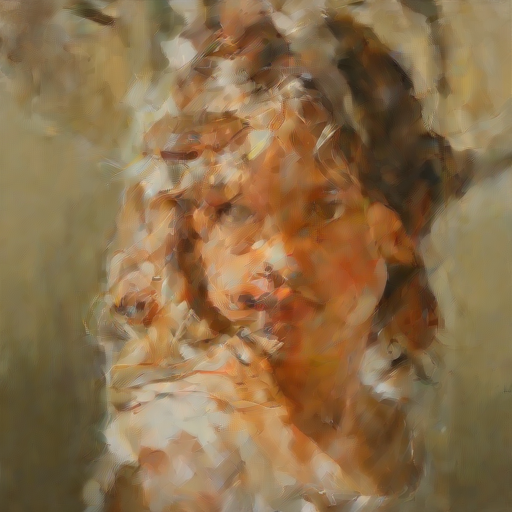

In [12]:
image1.save('oil painting of a little girl3.jpg')
image1

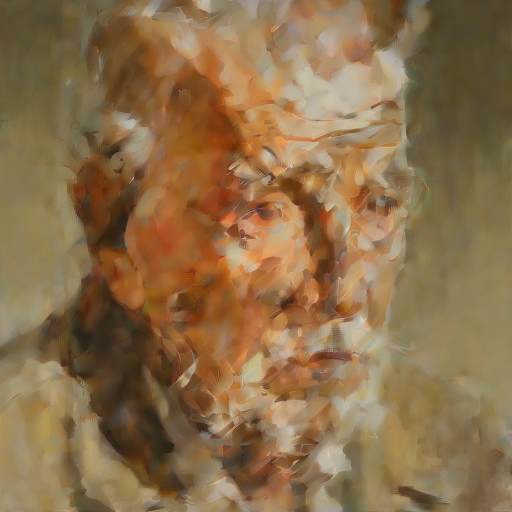

In [13]:
image2.save('oil painting of an elderly man3.jpg')
image2